Extracting EDF parameters from F:\Essencials\GitHub files\Predict_sleeping_using_EEG\Data set\sleep-edf-database-expanded-1.0.0\sleep-cassette\SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...


C:\Users\dmcol\AppData\Local\Temp\ipykernel_288\2430443617.py:11: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(file_path, preload=True)
C:\Users\dmcol\AppData\Local\Temp\ipykernel_288\2430443617.py:11: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(file_path, preload=True)
C:\Users\dmcol\AppData\Local\Temp\ipykernel_288\2430443617.py:11: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(file_path, preload=True)


All channels in file:
['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).

EEG data shape:
(2, 7950000)

Sampling frequency:
100.0
Using matplotlib as 2D backend.


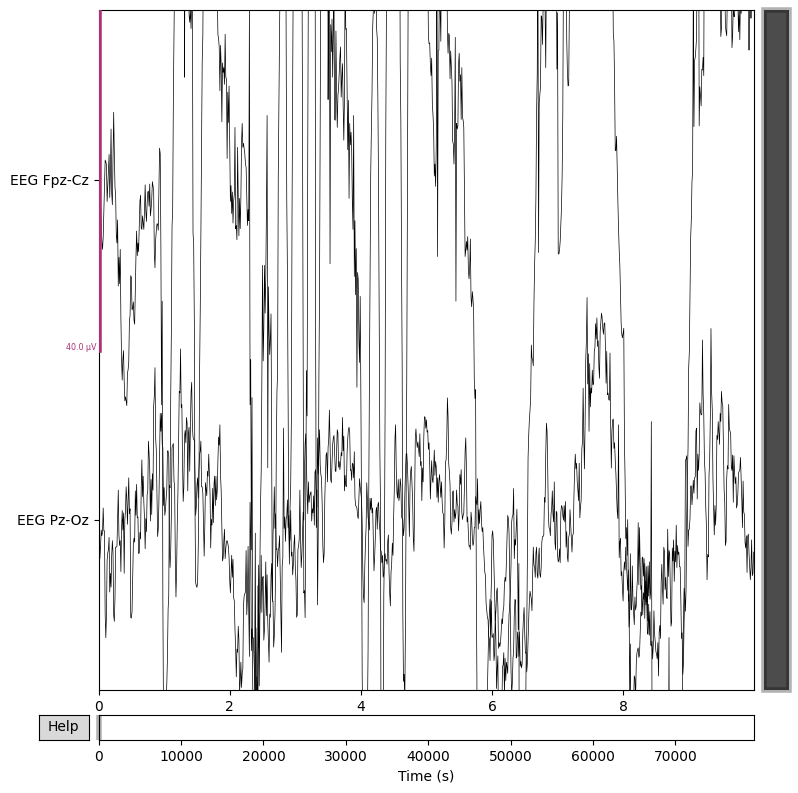

In [1]:
#load 1 data to check
import mne
import numpy as np
import matplotlib.pyplot as plt
import os

# Path to one PSG file (change this to your path)
file_path = r"F:\Essencials\GitHub files\Predict_sleeping_using_EEG\Data set\sleep-edf-database-expanded-1.0.0\sleep-cassette\SC4001E0-PSG.edf"

# Load EDF file
raw = mne.io.read_raw_edf(file_path, preload=True)

print("All channels in file:")
print(raw.ch_names)

# Pick only EEG channels
eeg_channels = ['EEG Fpz-Cz', 'EEG Pz-Oz']
raw_eeg = raw.copy().pick_channels(eeg_channels)

# Get data as numpy array
data = raw_eeg.get_data()

print("\nEEG data shape:")
print(data.shape)

print("\nSampling frequency:")
print(raw.info['sfreq'])

# Plot first 10 seconds
raw_eeg.plot(start=0, duration=10)
plt.show()




In [ ]:
import mne
import os
import glob
import numpy as np

# --- 1. CONFIGURATION ---
data_dir = r"F:\Essencials\GitHub files\Predict_sleeping_using_EEG\Data set\sleep-edf-database-expanded-1.0.0\sleep-cassette"
output_dir = os.path.join(data_dir, "processed_data")

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Mapping text labels to integers
# We combine Stage 3 and 4 into '3' (N3) as per modern AASM standards
mapping = {
    'Sleep stage W': 0,
    'Sleep stage 1': 1,
    'Sleep stage 2': 2,
    'Sleep stage 3': 3,
    'Sleep stage 4': 3,
    'Sleep stage R': 4
}

# Get all PSG and Hypnogram pairs
psg_files = sorted(glob.glob(os.path.join(data_dir, "*PSG.edf")))
hypno_files = sorted(glob.glob(os.path.join(data_dir, "*Hypnogram.edf")))

print(f"Found {len(psg_files)} subjects. Starting processing...")

# --- 2. THE PROCESSING LOOP ---
for psg_path, hypno_path in zip(psg_files, hypno_files):
    subject_id = os.path.basename(psg_path).replace("-PSG.edf", "")
    
    try:
        # A. Load Header and Select Channels
        raw = mne.io.read_raw_edf(psg_path, preload=False, verbose=False)
        raw.pick_channels(['EEG Fpz-Cz', 'EEG Pz-Oz'])
        raw.load_data(verbose=False)
        
        # B. Apply Butterworth 4th Order Filter (0.5 - 30 Hz) to remove muscle artifacts
        # This removes DC drift and high-frequency muscle noise
        raw.filter(l_freq=0.5, h_freq=30.0, method='iir', 
                   iir_params=dict(order=4, ftype='butter'), verbose=False)
        
        # C. Link Annotations (Labels)
        annotations = mne.read_annotations(hypno_path)
        
        # Filter annotations to keep only valid sleep stages
        # This prevents the "No matching events found" error
        valid_descriptions = [d for d in annotations.description if d in mapping]
        
        if not valid_descriptions:
            print(f"Skipping {subject_id}: No valid sleep stages found in hypnogram.")
            continue
            
        raw.set_annotations(annotations, emit_warning=False)
        
        # D. Create 30s Epochs
        # chunk_duration=30.0 cuts long labels into 30s segments
        events, event_id = mne.events_from_annotations(
            raw, event_id=mapping, chunk_duration=30.0, verbose=False
        )
        
        # on_missing='ignore' handles cases where a subject misses a specific stage
        epochs = mne.Epochs(
            raw=raw, events=events, event_id=event_id, 
            tmin=0., tmax=30. - 1./raw.info['sfreq'], 
            baseline=None, preload=True, 
            on_missing='ignore', verbose=False
        )
        
        if len(epochs) == 0:
            print(f"Skipping {subject_id}: 0 valid epochs generated.")
            continue

        # E. Extract Data and Labels
        x_data = epochs.get_data().astype(np.float32) # (Epochs, Channels, Times)
        y_data = epochs.events[:, -1].astype(np.int32) # (Epochs,)
        
        # F. Save to Disk
        np.save(os.path.join(output_dir, f"{subject_id}_X.npy"), x_data)
        np.save(os.path.join(output_dir, f"{subject_id}_y.npy"), y_data)
        
        print(f"Successfully processed {subject_id}: {len(y_data)} epochs saved.")
        
    except Exception as e:
        print(f"Error processing {subject_id}: {e}")

print("\n--- All subjects processed! Files saved in 'processed_data' ---")

Found 153 subjects. Starting processing...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\dmcol\AppData\Local\Temp\ipykernel_288\4194627140.py:36: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=False, verbose=False)
C:\Users\dmcol\AppData\Local\Temp\ipykernel_288\4194627140.py:36: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=False, verbose=False)
C:\Users\dmcol\AppData\Local\Temp\ipykernel_288\4194627140.py:36: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=False, verbose=False)


Successfully processed SC4001E0: 2650 epochs saved.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\dmcol\AppData\Local\Temp\ipykernel_288\4194627140.py:36: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=False, verbose=False)
C:\Users\dmcol\AppData\Local\Temp\ipykernel_288\4194627140.py:36: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=False, verbose=False)
C:\Users\dmcol\AppData\Local\Temp\ipykernel_288\4194627140.py:36: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=False, verbose=False)


Successfully processed SC4002E0: 2829 epochs saved.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


...

Successfully processed SC4812G0: 2414 epochs saved.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\dmcol\AppData\Local\Temp\ipykernel_288\4194627140.py:36: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=False, verbose=False)
C:\Users\dmcol\AppData\Local\Temp\ipykernel_288\4194627140.py:36: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=False, verbose=False)
C:\Users\dmcol\AppData\Local\Temp\ipykernel_288\4194627140.py:36: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=False, verbose=False)


Successfully processed SC4821G0: 2721 epochs saved.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\dmcol\AppData\Local\Temp\ipykernel_288\4194627140.py:36: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=False, verbose=False)
C:\Users\dmcol\AppData\Local\Temp\ipykernel_288\4194627140.py:36: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=False, verbose=False)
C:\Users\dmcol\AppData\Local\Temp\ipykernel_288\4194627140.py:36: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=False, verbose=False)


Successfully processed SC4822G0: 2810 epochs saved.

--- All subjects processed! Files saved in 'processed_data' ---


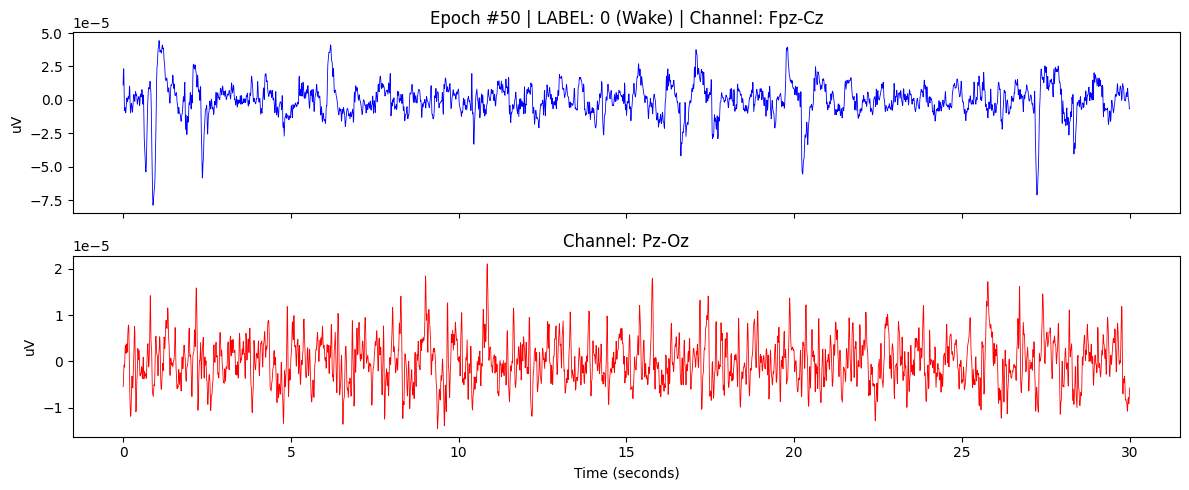

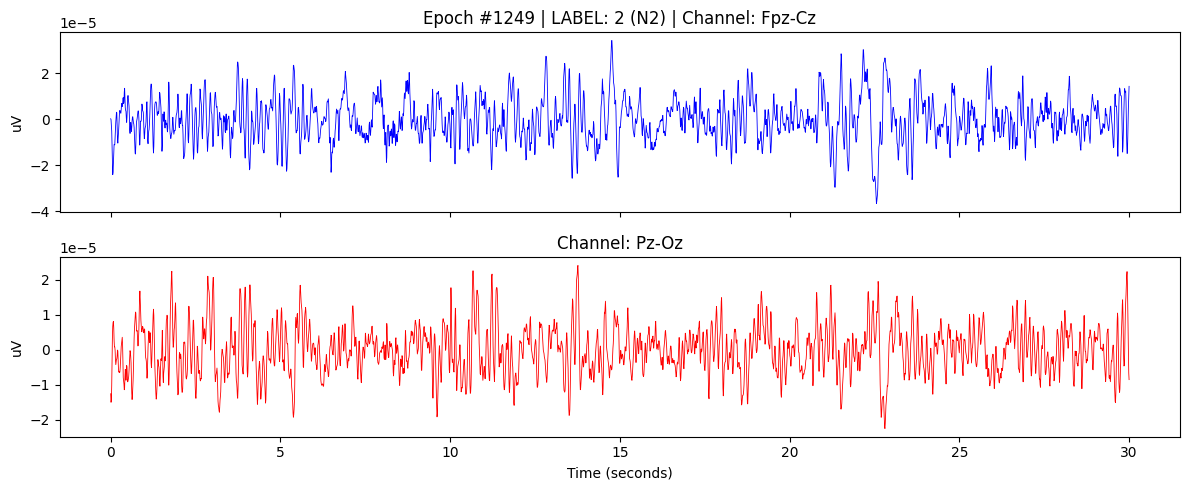

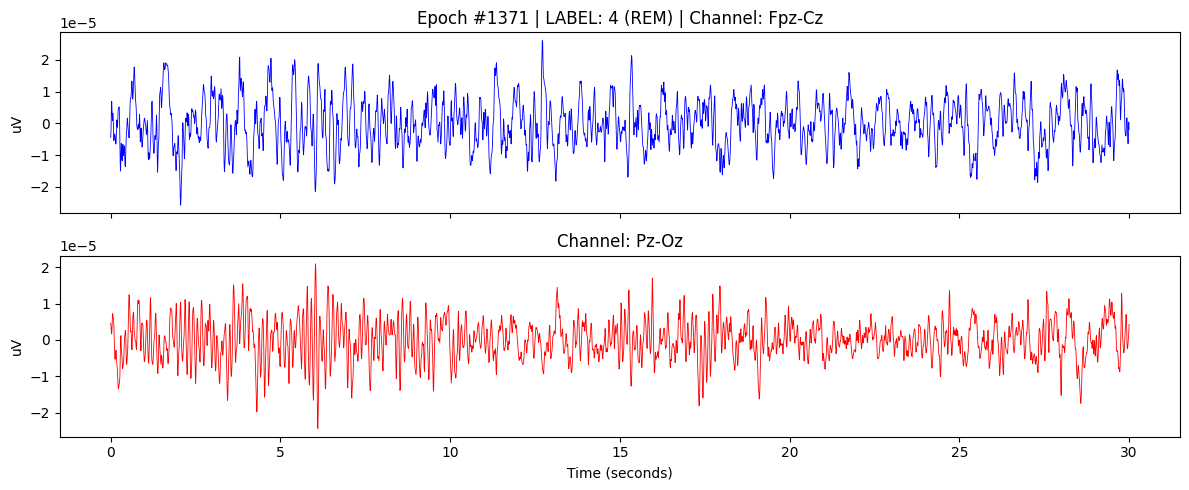

In [3]:
#visualize data

# Path to your processed data folder
processed_dir = r"F:\Essencials\GitHub files\Predict_sleeping_using_EEG\Data set\sleep-edf-database-expanded-1.0.0\sleep-cassette\processed_data"

# 1. Load the data for Subject 4001
X = np.load(os.path.join(processed_dir, "SC4001E0_X.npy"))
y = np.load(os.path.join(processed_dir, "SC4001E0_y.npy"))

# Mapping dictionary for labels
stage_names = {0: "Wake", 1: "N1", 2: "N2", 3: "N3", 4: "REM"}

# 2. Pick 3 different stages to visualize (e.g., Wake, N2, and REM)
stages_to_plot = [0, 2, 4] 
indices = []

for s in stages_to_plot:
    # Find the first few indices where this stage occurs and pick one
    idx_list = np.where(y == s)[0]
    if len(idx_list) > 0:
        indices.append(idx_list[50]) # Picking the 50th occurrence for variety

# 3. Create the plots
fs = 100 # 100Hz sampling rate
time = np.linspace(0, 30, 3000)

for idx in indices:
    epoch_data = X[idx]
    label_value = y[idx]
    label_name = stage_names[label_value]
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
    
    # Top Plot (Channel 1)
    axes[0].plot(time, epoch_data[0], color='blue', linewidth=0.6)
    axes[0].set_title(f"Epoch #{idx} | LABEL: {label_value} ({label_name}) | Channel: Fpz-Cz")
    axes[0].set_ylabel("uV")
    
    # Bottom Plot (Channel 2)
    axes[1].plot(time, epoch_data[1], color='red', linewidth=0.6)
    axes[1].set_title(f"Channel: Pz-Oz")
    axes[1].set_ylabel("uV")
    axes[1].set_xlabel("Time (seconds)")
    
    plt.tight_layout()
    plt.show()